<h1 style="color:#56B4E9;">Week 6 — Day 3</h1>

<h2 style="color:#0072B2;">Backpropagation, Gradient Descent, and Optimizers</h2>

### ECG-Based Multi-Label Cardiac Diagnosis Using PTB-XL

Day 2 explained how ECG features move forward through a neural network and how Binary Cross-Entropy measures prediction error. Day 3 completes the training loop by calculating how each trainable parameter contributed to the loss and updating the parameters to reduce future errors.

<h2 style="color:#0072B2;">Learning Objectives</h2>

By the end of this notebook, we will be able to:

- Describe the four-step neural-network training loop.
- Explain Gradient Descent and the role of the learning rate.
- Explain Backpropagation and why the chain rule is required.
- Distinguish between an optimizer, an epoch, and a batch.
- Compare training behavior at low, suitable, and high learning rates.

<h2 style="color:#0072B2;">1. The Complete Training Loop</h2>

Training repeatedly performs four steps:

$$
\text{Forward Pass} \rightarrow \text{Loss} \rightarrow \text{Backpropagation} \rightarrow \text{Update}
$$

For two hidden layers and one output layer, the forward pass is:

$$
Z_1=XW_1+b_1, \qquad A_1=ReLU(Z_1)
$$

$$
Z_2=A_1W_2+b_2, \qquad A_2=ReLU(Z_2)
$$

$$
Z_3=A_2W_3+b_3, \qquad \hat{Y}=Sigmoid(Z_3)
$$

The four outputs are independent disease probabilities:

$$
\hat{Y}=[\hat y_{MI},\hat y_{STTC},\hat y_{CD},\hat y_{HYP}]
$$

For one disease, Binary Cross-Entropy is:

$$
L(y,\hat y)=-[y\log(\hat y)+(1-y)\log(1-\hat y)]
$$

The network averages the four disease losses for every sample, then averages the sample losses within the current batch.

<h2 style="color:#0072B2;">2. Backpropagation and the Chain Rule</h2>

A weight in an early layer does not affect the loss directly. It first changes the weighted sum, which changes the activation, which changes later layers, predictions, and finally the loss. Backpropagation follows these relationships in reverse.

For an output-layer weight:

$$
\frac{\partial L}{\partial W_3}=\frac{\partial L}{\partial \hat Y}\cdot\frac{\partial \hat Y}{\partial Z_3}\cdot\frac{\partial Z_3}{\partial W_3}
$$

For a weight in the first hidden layer, the chain is longer:

$$
\frac{\partial L}{\partial W_1}=\frac{\partial L}{\partial \hat Y}\cdot\frac{\partial \hat Y}{\partial Z_3}\cdot\frac{\partial Z_3}{\partial A_2}\cdot\frac{\partial A_2}{\partial Z_2}\cdot\frac{\partial Z_2}{\partial A_1}\cdot\frac{\partial A_1}{\partial Z_1}\cdot\frac{\partial Z_1}{\partial W_1}
$$

Each derivative describes one local relationship. Their product gives the total effect of the weight on the loss:

$$
Gradient=\frac{\partial L}{\partial W}
$$

In simple words, Backpropagation assigns a share of the error to every weight and bias. TensorFlow calculates these gradients automatically, but the chain rule explains how an early parameter can be connected mathematically to the final loss.

<h2 style="color:#0072B2;">3. Gradient Descent and the Learning Rate</h2>

The gradient points toward the direction of the steepest increase in loss. Gradient Descent moves in the opposite direction:

$$
W_{new}=W_{old}-\eta\frac{\partial L}{\partial W}
$$

where $\eta$ is the learning rate.

- A very low learning rate produces tiny updates and slow training.
- A suitable learning rate reduces the loss efficiently and steadily.
- A very high learning rate may overshoot useful weight values, producing instability or a poor solution.

The optimizer applies the updates. SGD performs the basic gradient update, while Adam also uses information from previous gradients and adapts the effective step for each parameter. Adam with a learning rate near `0.001` is a reliable starting point, but it still needs experimental verification.

<h3 style="color:#009E73;">The Loss Surface</h3>

The loss surface represents how the loss changes when the network weights change. Each point on this surface corresponds to one possible combination of weight values and its resulting loss.

With one or two weights, the surface can be visualized as a curve or a three-dimensional landscape. A real neural network contains many weights, so its loss surface has many dimensions and cannot be drawn directly.

The gradient identifies the direction of the steepest increase on this surface. Gradient Descent moves the weights in the opposite direction to search for a region with lower loss.

In [1]:
from pathlib import Path
import ast
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb
import tensorflow as tf

from sklearn.preprocessing import StandardScaler

I0000 00:00:1787684132.134828   16148 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787684132.135597   16148 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787684132.204604   16148 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787684133.738651   16148 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

DATA_DIR = Path("../../cardiac-patient-monitoring/data/raw/ptb-xl")
metadata_path = DATA_DIR / "ptbxl_database.csv"
statements_path = DATA_DIR / "scp_statements.csv"

print("TensorFlow version:", tf.__version__)
print("Metadata exists:", metadata_path.exists())
print("Statements exist:", statements_path.exists())
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0
Metadata exists: True
Statements exist: True
GPU devices: []


E0000 00:00:1787684134.743160   16148 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


<h3 style="color:#009E73;">Environment Check</h3>

TensorFlow `2.21.0` loaded successfully. No CUDA-compatible GPU was available, so TensorFlow used the CPU. This does not prevent the experiment because the network and the statistical feature table are small enough for CPU training.

In [3]:
metadata = pd.read_csv(metadata_path, index_col="ecg_id")
scp_statements = pd.read_csv(statements_path, index_col=0)
metadata["scp_codes_dict"] = metadata["scp_codes"].apply(ast.literal_eval)

available_ids = []
for ecg_id, row in metadata.iterrows():
    record_path = DATA_DIR / row["filename_lr"]
    if record_path.with_suffix(".dat").exists() and record_path.with_suffix(".hea").exists():
        available_ids.append(ecg_id)

available_metadata = metadata.loc[available_ids].copy()
print("Complete ECG recordings:", len(available_metadata))

Complete ECG recordings: 21799


In [4]:
def get_diagnostic_classes(code_dictionary):
    classes = []
    for code in code_dictionary:
        if code not in scp_statements.index:
            continue
        is_diagnostic = scp_statements.loc[code, "diagnostic"]
        diagnostic_class = scp_statements.loc[code, "diagnostic_class"]
        if is_diagnostic == 1 and pd.notna(diagnostic_class) and diagnostic_class not in classes:
            classes.append(diagnostic_class)
    return classes

available_metadata["diagnostic_classes"] = available_metadata["scp_codes_dict"].apply(get_diagnostic_classes)
selection_classes = ["NORM", "MI", "STTC", "CD", "HYP"]
target_classes = ["MI", "STTC", "CD", "HYP"]

for class_name in selection_classes:
    available_metadata[class_name] = available_metadata["diagnostic_classes"].apply(lambda classes: int(class_name in classes))

model_data = available_metadata[available_metadata[selection_classes].sum(axis=1) > 0].copy()
print("ECGs used for modeling:", len(model_data))

ECGs used for modeling: 21388


In [5]:
feature_rows = []

for ecg_id, row in model_data.iterrows():
    signal, information = wfdb.rdsamp(str(DATA_DIR / row["filename_lr"]))
    features = {"ecg_id": ecg_id}

    for lead_index, lead_name in enumerate(information["sig_name"]):
        lead = signal[:, lead_index]
        features[f"{lead_name}_mean"] = np.mean(lead)
        features[f"{lead_name}_std"] = np.std(lead)
        features[f"{lead_name}_min"] = np.min(lead)
        features[f"{lead_name}_max"] = np.max(lead)
        features[f"{lead_name}_range"] = np.max(lead) - np.min(lead)
        features[f"{lead_name}_rms"] = np.sqrt(np.mean(lead ** 2))

    feature_rows.append(features)

X = pd.DataFrame(feature_rows).set_index("ecg_id")
y = model_data.loc[X.index, target_classes].astype("float32")
print("Feature table shape:", X.shape)

Feature table shape: (21388, 72)


In [6]:
train_ids = model_data[model_data["strat_fold"].between(1, 8)].index
validation_ids = model_data[model_data["strat_fold"] == 9].index
test_ids = model_data[model_data["strat_fold"] == 10].index

X_train = X.loc[X.index.intersection(train_ids)]
X_validation = X.loc[X.index.intersection(validation_ids)]
X_test = X.loc[X.index.intersection(test_ids)]

y_train = y.loc[X_train.index]
y_validation = y.loc[X_validation.index]
y_test = y.loc[X_test.index]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype("float32")
X_validation_scaled = scaler.transform(X_validation).astype("float32")
X_test_scaled = scaler.transform(X_test).astype("float32")

y_train_array = y_train.to_numpy(dtype="float32")
y_validation_array = y_validation.to_numpy(dtype="float32")
y_test_array = y_test.to_numpy(dtype="float32")

In [7]:
print("Training:", X_train_scaled.shape, y_train_array.shape)
print("Validation:", X_validation_scaled.shape, y_validation_array.shape)
print("Test:", X_test_scaled.shape, y_test_array.shape)
print("\nTraining label counts:")
print(y_train.sum().astype(int))
print("\nRows with four zero disease labels:", int((y_train.sum(axis=1) == 0).sum()))
print("Missing or infinite values:", int(np.size(X_train_scaled) - np.isfinite(X_train_scaled).sum()))

Training: (17084, 72) (17084, 4)
Validation: (2146, 72) (2146, 4)
Test: (2158, 72) (2158, 4)

Training label counts:
MI      4379
STTC    4186
CD      3907
HYP     2119
dtype: int64

Rows with four zero disease labels: 7243
Missing or infinite values: 0


<h3 style="color:#009E73;">Prepared Data Results</h3>

All `21,799` PTB-XL recordings were available. After removing recordings outside the five selected diagnostic superclasses, `21,388` ECGs remained. Each recording was represented by 72 features: six statistics from each of the 12 leads.

The official PTB-XL folds produced:

- Training: `(17084, 72)`
- Validation: `(2146, 72)`
- Test: `(2158, 72)`

The training targets contained 4,379 MI labels, 4,186 STTC labels, 3,907 CD labels, and 2,119 HYP labels. A total of 7,243 training rows had four zero disease labels. These include the normal examples used to teach the network what the absence of the four target diseases looks like. No missing or infinite input values were found.

<h2 style="color:#0072B2;">4. Epochs, Batches, and the Experiment</h2>

An epoch is one complete pass through all training records. A batch is the subset processed before one weight update. With 17,084 training records and `batch_size=32`, the network performs approximately:

$$
\left\lceil\frac{17084}{32}\right\rceil=534
$$

updates per epoch. During 40 epochs, each experiment performs approximately:

$$
534\times40=21,360
$$

weight updates.

The same architecture, data, seed, batch size, loss, and Adam optimizer are used in all experiments. Only the learning rate changes: `1e-6`, `1e-3`, and `1.0`. Resetting the seed before creating each model makes the comparison fair by reproducing the same initial conditions as closely as possible.

In [8]:
def build_model(learning_rate):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(72,)),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(4, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy"
    )
    return model

model = build_model(1e-3)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,932 (11.45 KB)

 Trainable params: 2,932 (11.45 KB)

 Non-trainable params: 0 (0.00 B)

<h3 style="color:#009E73;">Architecture Dimensions</h3>

For a batch of size $B$, the first layer performs:

$$
(B,72)(72,32)+(32)=(B,32)
$$

The second layer performs:

$$
(B,32)(32,16)+(16)=(B,16)
$$

The output layer performs:

$$
(B,16)(16,4)+(4)=(B,4)
$$

ReLU is used in the hidden layers to learn non-linear relationships. Four independent sigmoid neurons output the probabilities of MI, STTC, CD, and HYP.

In [9]:
learning_rates = {
    "Too Low: 1e-6": 1e-6,
    "Suitable: 1e-3": 1e-3,
    "Too High: 1.0": 1.0
}

histories = {}
result_rows = []

for experiment, learning_rate in learning_rates.items():
    print("Training:", experiment)
    model = build_model(learning_rate)
    history = model.fit(
        X_train_scaled, y_train_array,
        validation_data=(X_validation_scaled, y_validation_array),
        epochs=40, batch_size=32, verbose=0
    )
    histories[experiment] = history.history

    result_rows.append({
        "Experiment": experiment,
        "Initial Train Loss": history.history["loss"][0],
        "Final Train Loss": history.history["loss"][-1],
        "Best Validation Loss": np.min(history.history["val_loss"]),
        "Best Epoch": np.argmin(history.history["val_loss"]) + 1,
        "Final Validation Loss": history.history["val_loss"][-1]
    })

results = pd.DataFrame(result_rows).set_index("Experiment")
display(results.round(4))

Training: Too Low: 1e-6
Training: Suitable: 1e-3
Training: Too High: 1.0


,Initial Train Loss,Final Train Loss,Best Validation Loss,Best Epoch,Final Validation Loss
Experiment,,,,,
Too Low: 1e-6,0.7724,0.6699,0.6628,40,0.6628
Suitable: 1e-3,0.4656,0.3539,0.3946,29,0.4021
Too High: 1.0,0.9453,0.5230,0.5120,1,0.5125


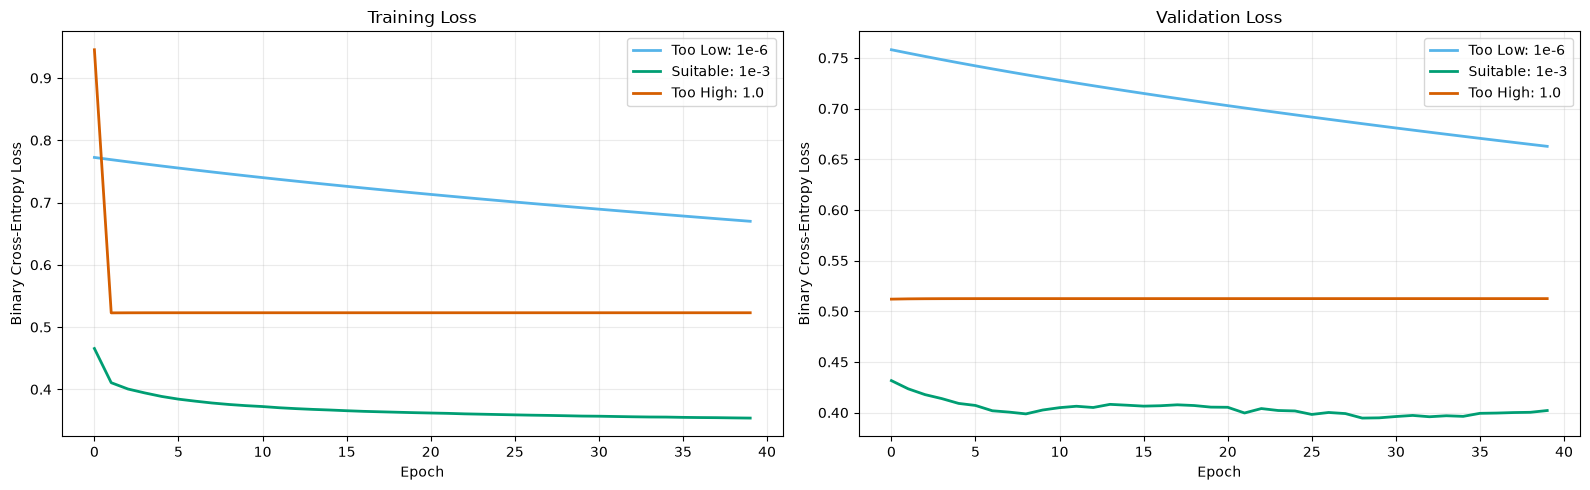

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = ["#56B4E9", "#009E73", "#D55E00"]

for (experiment, history), color in zip(histories.items(), colors):
    axes[0].plot(history["loss"], label=experiment, color=color, linewidth=2)
    axes[1].plot(history["val_loss"], label=experiment, color=color, linewidth=2)

axes[0].set_title("Training Loss")
axes[1].set_title("Validation Loss")

for axis in axes:
    axis.set_xlabel("Epoch")
    axis.set_ylabel("Binary Cross-Entropy Loss")
    axis.grid(alpha=0.25)
    axis.legend()

plt.tight_layout()
plt.show()

<h2 style="color:#0072B2;">5. Learning-Rate Results</h2>

| Experiment | Initial Train Loss | Final Train Loss | Best Validation Loss | Best Epoch | Final Validation Loss |
|---|---:|---:|---:|---:|---:|
| Too Low: `1e-6` | 0.7724 | 0.6699 | 0.6628 | 40 | 0.6628 |
| Suitable: `1e-3` | 0.4656 | 0.3539 | **0.3946** | 29 | 0.4021 |
| Too High: `1.0` | 0.9453 | 0.5230 | 0.5120 | 1 | 0.5125 |

<h3 style="color:#009E73;">Too Low: 1e-6</h3>

Both curves decreased smoothly, proving that the model was learning. However, the reduction was extremely slow. Even after 40 epochs, validation loss was still `0.6628`. The steps were safe but too small to reach a useful region efficiently. Because the best validation result occurred at epoch 40, additional epochs would probably continue reducing the loss, but at an inefficient rate.

<h3 style="color:#009E73;">Suitable: 1e-3</h3>

This experiment produced the lowest losses. Training loss decreased from `0.4656` to `0.3539`, while the best validation loss reached `0.3946` at epoch 29. The curve decreased rapidly at the beginning and then improved more gradually. After epoch 29, training loss continued decreasing while validation loss varied slightly and ended at `0.4021`. This small gap indicates the beginning of overfitting, so retaining the weights from the best validation epoch would be preferable.

<h3 style="color:#D55E00;">Too High: 1.0</h3>

The first training loss was very high at `0.9453`. It then dropped rapidly to approximately `0.523`, but almost completely stopped improving. Validation loss was already best at epoch 1 and remained near `0.512`. The optimizer did not produce `NaN`, but the learning rate was still too aggressive: large updates moved the network into a weak region from which useful fine adjustments were not achieved. A high learning rate does not always create visible oscillations; it may also produce fast movement followed by stagnation at a poor solution.

The experiment therefore supports `Adam(learning_rate=0.001)` as the best of the three tested settings.

<h2 style="color:#0072B2;">6. Day 3 Conclusion</h2>

Day 3 completed the neural-network training loop. Forward propagation used the current parameters to produce four disease probabilities, Binary Cross-Entropy measured their error, Backpropagation used the chain rule to calculate a gradient for every trainable parameter, and Adam used those gradients to update the parameters.

The controlled experiment showed that the learning rate changes both training speed and the quality of the solution. A learning rate of `1e-6` was stable but inefficient, `1.0` produced a rapid but weak and stagnant result, and `1e-3` produced the best validation loss. The best validation epoch was 29, demonstrating why validation monitoring and saving the best model are more reliable than automatically using the final epoch.

### Final Project Decisions

- Optimizer: Adam
- Learning rate: `0.001`
- Batch size: `32`
- Hidden activations: ReLU
- Output activation: Sigmoid
- Loss: Binary Cross-Entropy
- Preferred checkpoint: best validation epoch

The next development step is to add training callbacks, evaluate disease-specific predictions, and compare the neural network with the Day 1 baseline using recall, precision, and F1-score rather than loss alone.

### Mentor Review Checkpoint

The current project notebook is ready for a mid-sprint code and notebook review. The pull request should include the Day 1–3 notebooks, describe the four-label ECG task, summarize the learning-rate experiment, and record any mentor feedback before the next modeling stage.